In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df=pd.read_csv('charging_station.csv')
df.head()

,id,name,city,state_province,country_code,latitude,longitude,ports,power_kw,power_class,is_fast_dc
0,307660,Av. de Tarragona,Andorra,UNKNOWN,AD,42.505254,1.528861,10,300.0,DC_ULTRA_(>=150kW),True
1,301207,Parquing Costa Rodona,Encamp,UNKNOWN,AD,42.537213,1.727014,10,22.0,AC_HIGH_(22-49kW),False
2,301206,Hotel Naudi,Unknown City,UNKNOWN,AD,42.576811,1.666061,1,11.0,AC_L2_(7.5-21kW),False
3,301205,Hotel Piolets Soldeu Centre,Unknown City,UNKNOWN,AD,42.576466,1.667317,1,22.0,AC_HIGH_(22-49kW),False
4,301204,Hotel Serras,Unknown City,UNKNOWN,AD,42.579458,1.659215,3,11.0,AC_L2_(7.5-21kW),False


In [7]:
df.shape

(242417, 11)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 242417 entries, 0 to 242416
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   id              242417 non-null  int64  
 1   name            242417 non-null  object 
 2   city            242417 non-null  object 
 3   state_province  242417 non-null  object 
 4   country_code    242417 non-null  object 
 5   latitude        242417 non-null  float64
 6   longitude       242417 non-null  float64
 7   ports           242417 non-null  int64  
 8   power_kw        237757 non-null  float64
 9   power_class     242417 non-null  object 
 10  is_fast_dc      242417 non-null  bool   
dtypes: bool(1), float64(3), int64(2), object(5)
memory usage: 18.7+ MB


In [9]:
df.describe(include="all")

,id,name,city,state_province,country_code,latitude,longitude,ports,power_kw,power_class,is_fast_dc
count,242417.000000,242417,242417,242417,242417,242417.000000,242417.000000,242417.000000,237757.000000,242417,242417
unique,NaN,225282,41816,5989,121,NaN,NaN,NaN,NaN,6,2
top,NaN,Shell Recharge/Ubitricity,Unknown City,UNKNOWN,US,NaN,NaN,NaN,NaN,AC_L1_(<7.5kW),False
freq,NaN,1166,22189,69998,82138,NaN,NaN,NaN,NaN,107144,191584
mean,204039.926519,NaN,NaN,NaN,NaN,43.253894,-32.074160,1.959277,35.253735,NaN,NaN
std,101789.186799,NaN,NaN,NaN,NaN,12.692335,57.652645,3.931007,2051.557432,NaN,NaN
min,2389.000000,NaN,NaN,NaN,NaN,-55.811599,-164.848855,-4.000000,0.000000,NaN,NaN
25%,122882.000000,NaN,NaN,NaN,NaN,38.859333,-81.644018,1.000000,3.700000,NaN,NaN
50%,208085.000000,NaN,NaN,NaN,NaN,44.414623,-2.867264,1.000000,11.000000,NaN,NaN
75%,280795.000000,NaN,NaN,NaN,NaN,51.413890,7.883693,2.000000,22.000000,NaN,NaN


In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.isnull().sum()

id                   0
name                 0
city                 0
state_province       0
country_code         0
latitude             0
longitude            0
ports                0
power_kw          4660
power_class          0
is_fast_dc           0
dtype: int64

In [12]:
df.nunique()

id                242417
name              225282
city               41816
state_province      5989
country_code         121
latitude          236003
longitude         236946
ports                113
power_kw             313
power_class            6
is_fast_dc             2
dtype: int64

In [13]:
df[df['ports'] <= 0][
    ['id', 'name', 'city', 'country_code', 'ports']
].head(20)

,id,name,city,country_code,ports
2640,131841,Wollongong Central - P1 Basement Car Park,Wollongong,AU,0
19023,111808,TD Canada Trust,Victoria,CA,0
20405,74166,Duplcate Listing Removed,Granby,CA,0
23017,88961,Centrum Eden,okres Žďár nad Sázavou,CZ,0
39128,85626,Rolf Fischer GmbH,Bargstedt,DE,0
39550,83983,Supermarkt Aldi,Unterhaching,DE,0
69274,74768,Sodankyläntie,Rovaniemen seutukunta,FI,0
98774,194151,Factory Road Lamppost Charger,Eastleigh,GB,0
108818,40995,The Lodge at Birkby Hall,Brighouse,GB,-4
110733,4517,HK Electric ex-Operation Headquarters,Ap Lei Chau,HK,0


In [14]:
df[df['ports'] > 100][
    ['id', 'name', 'city', 'country_code', 'ports']
].sort_values('ports', ascending=False).head(20)

,id,name,city,country_code,ports
154665,238666,Hagastaden P-hus västra,STOCKHOLM,SE,503
160042,459034,45 W. Arctic Ave,Folly Beach,US,500
142040,157061,Oslo lufthavn P10,GARDERMOEN,NO,379
143096,46432,Oslo lufthavn P11,GARDERMOEN,NO,348
154430,242591,NK Parkering,STOCKHOLM,SE,325
120120,167854,BE CHARGE - CENTRO SME Via dei Laghi,San Donà di Piave,IT,324
52461,301762,BP Pulse Coop Sta. María del Águila,El Ejido,ES,300
154664,238667,"Hagastaden P-hus, mitt",STOCKHOLM,SE,295
23300,458939,Bahnhof Merklingen - Schwäbische Alb,Merklingen,DE,259
131443,311591,Efteling Parking,Kaatsheuvel,NL,242


In [15]:
df[df['power_kw'] <= 0][
    ['id', 'name', 'city', 'country_code', 'power_kw']
].head(20)

,id,name,city,country_code,power_kw
43051,54259,BMW Graubaum,Berlin,DE,0.0
43068,54235,AHG Automobile,Villingen Schweningen,DE,0.0
48966,192363,xx (creado por error),Casa de Campo,DO,0.0
128425,168016,Pasteur (Street 51),Khan Boeng Keng Kang,KH,0.0
128426,167993,Sivatha Boulevard,Unknown City,KH,0.0
149819,271794,Pivnița Bunicii,Saschiz,RO,0.0
150655,310509,Novomet DC60,Unknown City,RU,0.0
150659,310377,Префектура ВАО г. Москвы DC60,Unknown City,RU,0.0
150661,310366,"Борисхоф, Балашиха, Ресепшн",Unknown City,RU,0.0
150662,310359,Сидней-Сити AC22 (ФСК),Unknown City,RU,0.0


In [16]:
df[df['power_kw'] > 1000][
    ['id', 'name', 'city', 'country_code', 'power_kw']
].sort_values('power_kw', ascending=False).head(20)

,id,name,city,country_code,power_kw
115232,311284,SRM Institute of science and technology,chennai,IN,1000000.0


In [17]:
df['power_class'].value_counts(dropna=False)

power_class
AC_L1_(<7.5kW)        107144
AC_HIGH_(22-49kW)      55542
DC_FAST_(50-149kW)     37329
AC_L2_(7.5-21kW)       24238
DC_ULTRA_(>=150kW)     13504
UNKNOWN                 4660
Name: count, dtype: int64

In [18]:
df['is_fast_dc'].value_counts(dropna=False)

is_fast_dc
False    191584
True      50833
Name: count, dtype: int64

In [19]:
df['country_code'].value_counts().head(20)

country_code
US    82138
GB    26825
DE    23373
ES    17825
CA    16490
FR    13820
IT    10354
NL     8091
SE     4953
NO     4790
PT     3696
RU     2203
DK     2178
IE     2002
FI     1873
JP     1641
AT     1282
TR     1278
BE     1245
AU     1241
Name: count, dtype: int64

In [20]:
df['state_province'].value_counts().head(20)

state_province
UNKNOWN    69998
CA         17528
QC          5579
NY          5259
ON          5012
FL          4412
TX          4371
MA          3343
CO          2822
BC          2713
WA          2705
MI          2411
GA          2392
PA          2159
NC          2118
OH          2005
MD          1999
VA          1978
IL          1851
OR          1791
Name: count, dtype: int64

In [21]:
print("Invalid latitude:")
print(df[(df['latitude'] < -90) | (df['latitude'] > 90)].shape)

print("Invalid longitude:")
print(df[(df['longitude'] < -180) | (df['longitude'] > 180)].shape)

Invalid latitude:
(0, 11)
Invalid longitude:
(0, 11)


In [22]:
df[['latitude', 'longitude']].isnull().sum()

latitude     0
longitude    0
dtype: int64

In [23]:
for col in ['name', 'city', 'state_province', 'country_code']:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(dropna=False).head(15))


--- name ---
name
Shell Recharge/Ubitricity            1166
SWTCH Energy Inc.                     331
Rathaus                               244
Swtch Energy                          242
Comfortcharge Ladestation             234
opp.                                  118
Wawa - Tesla Supercharger             117
Opp.                                  105
Google                                 99
Bahnhof                                92
First Capital Asset Management LP      89
Lidl                                   82
IRVINE CO OFC                          78
Sheetz - Tesla Supercharger            67
SWTCH Energy                           65
Name: count, dtype: int64

--- city ---
city
Unknown City    22189
London           7665
Los Angeles      2128
Hammersmith      1118
Montréal          991
Berlin            827
Toronto           767
San Diego         758
Atlanta           681
Austin            650
Hamburg           627
New York          549
OSLO              545
Houston           54

In [24]:
df[df['power_kw'] <= 0][
    ['id', 'name', 'city', 'country_code', 'power_kw', 'power_class']
].head(20)

,id,name,city,country_code,power_kw,power_class
43051,54259,BMW Graubaum,Berlin,DE,0.0,AC_L1_(<7.5kW)
43068,54235,AHG Automobile,Villingen Schweningen,DE,0.0,AC_L1_(<7.5kW)
48966,192363,xx (creado por error),Casa de Campo,DO,0.0,AC_L1_(<7.5kW)
128425,168016,Pasteur (Street 51),Khan Boeng Keng Kang,KH,0.0,AC_L1_(<7.5kW)
128426,167993,Sivatha Boulevard,Unknown City,KH,0.0,AC_L1_(<7.5kW)
149819,271794,Pivnița Bunicii,Saschiz,RO,0.0,AC_L1_(<7.5kW)
150655,310509,Novomet DC60,Unknown City,RU,0.0,AC_L1_(<7.5kW)
150659,310377,Префектура ВАО г. Москвы DC60,Unknown City,RU,0.0,AC_L1_(<7.5kW)
150661,310366,"Борисхоф, Балашиха, Ресепшн",Unknown City,RU,0.0,AC_L1_(<7.5kW)
150662,310359,Сидней-Сити AC22 (ФСК),Unknown City,RU,0.0,AC_L1_(<7.5kW)


In [25]:
df[df['power_kw'] > 1000][
    ['id', 'name', 'city', 'country_code', 'power_kw', 'power_class']
].sort_values('power_kw', ascending=False).head(30)

,id,name,city,country_code,power_kw,power_class
115232,311284,SRM Institute of science and technology,chennai,IN,1000000.0,DC_ULTRA_(>=150kW)


In [26]:
df[df['power_kw'] > 100][
    ['id', 'name', 'city', 'country_code', 'power_kw', 'power_class']
].sort_values('power_kw', ascending=False).head(30)

,id,name,city,country_code,power_kw,power_class
115232,311284,SRM Institute of science and technology,chennai,IN,1000000.0,DC_ULTRA_(>=150kW)
146092,306657,Parking Transfronterizo Fuentes de Oñoro,Vilar Formoso,PT,1000.0,DC_ULTRA_(>=150kW)
56868,256766,Disfrimur - Calle Río Ebro,Unknown City,ES,1000.0,DC_ULTRA_(>=150kW)
130057,300087,Yangon,Yangon,MM,1000.0,DC_ULTRA_(>=150kW)
130147,273906,Supercool Mobility Center,San Lorenzo Almecatla,MX,990.0,DC_ULTRA_(>=150kW)
131061,311348,JPO Commercial EV Hub by DC Handal,Kulai,MY,640.0,DC_ULTRA_(>=150kW)
186996,312541,Tractor Supply Company,Chipley,US,600.0,DC_ULTRA_(>=150kW)
86696,268359,MOTO Donington Park Services,Castle Donington,GB,560.0,DC_ULTRA_(>=150kW)
131511,274104,Boerderijwinkel Lagerweij,Buurmalsen,NL,501.0,DC_ULTRA_(>=150kW)
154957,215042,Engströms Lastbilar - EVBox,LINKÖPING,SE,500.0,DC_ULTRA_(>=150kW)


In [27]:
pd.crosstab(
    df['power_class'],
    df['is_fast_dc']
)

is_fast_dc,False,True
power_class,,
AC_HIGH_(22-49kW),55542,0
AC_L1_(<7.5kW),107144,0
AC_L2_(7.5-21kW),24238,0
DC_FAST_(50-149kW),0,37329
DC_ULTRA_(>=150kW),0,13504
UNKNOWN,4660,0


In [28]:
df.groupby('power_class')['power_kw'].agg(
    ['count', 'min', 'median', 'mean', 'max']
).sort_values('median')

,count,min,median,mean,max
power_class,,,,,
AC_L1_(<7.5kW),107144,0.0,3.7,4.174050,7.4
AC_L2_(7.5-21kW),24238,7.5,11.0,12.586372,21.6
AC_HIGH_(22-49kW),55542,22.0,22.0,23.604559,49.0
DC_FAST_(50-149kW),37329,50.0,50.0,59.600742,149.0
DC_ULTRA_(>=150kW),13504,150.0,200.0,303.143424,1000000.0
UNKNOWN,0,NaN,NaN,NaN,NaN


In [29]:
print("Ports <= 0:", (df['ports'] <= 0).sum())
print("Ports == 0:", (df['ports'] == 0).sum())
print("Ports < 0:", (df['ports'] < 0).sum())
print("Ports > 100:", (df['ports'] > 100).sum())

Ports <= 0: 15
Ports == 0: 14
Ports < 0: 1
Ports > 100: 29


In [30]:
df['ports'].value_counts().sort_index().head(20)

ports
-4          1
 0         14
 1     164869
 2      45312
 3       5219
 4      12539
 5       1092
 6       4380
 7        422
 8       3225
 9        293
 10      1109
 11       117
 12      1352
 13        66
 14       277
 15        85
 16       587
 17        29
 18       171
Name: count, dtype: int64

In [31]:
df['ports'].describe()

count    242417.000000
mean          1.959277
std           3.931007
min          -4.000000
25%           1.000000
50%           1.000000
75%           2.000000
max         503.000000
Name: ports, dtype: float64

In [32]:
print(
    "Invalid latitude:",
    ((df['latitude'] < -90) | (df['latitude'] > 90)).sum()
)

print(
    "Invalid longitude:",
    ((df['longitude'] < -180) | (df['longitude'] > 180)).sum()
)

print("Latitude duplicates:", df['latitude'].duplicated().sum())
print("Longitude duplicates:", df['longitude'].duplicated().sum())

Invalid latitude: 0
Invalid longitude: 0
Latitude duplicates: 6414
Longitude duplicates: 5471


In [33]:
unknown_summary = pd.DataFrame({
    'column': ['city', 'state_province', 'country_code'],
    'unknown_count': [
        (df['city'] == 'Unknown City').sum(),
        (df['state_province'] == 'UNKNOWN').sum(),
        (df['country_code'] == 'UNKNOWN').sum()
    ]
})

unknown_summary

,column,unknown_count
0,city,22189
1,state_province,69998
2,country_code,0


In [34]:
print("Unknown City %:",
      (df['city'] == 'Unknown City').mean() * 100)

print("Unknown State %:",
      (df['state_province'] == 'UNKNOWN').mean() * 100)

Unknown City %: 9.153235952924094
Unknown State %: 28.875037641749547


In [35]:
df['power_class'].value_counts()

power_class
AC_L1_(<7.5kW)        107144
AC_HIGH_(22-49kW)      55542
DC_FAST_(50-149kW)     37329
AC_L2_(7.5-21kW)       24238
DC_ULTRA_(>=150kW)     13504
UNKNOWN                 4660
Name: count, dtype: int64

In [36]:
df['is_fast_dc'].value_counts()

is_fast_dc
False    191584
True      50833
Name: count, dtype: int64

In [37]:
pd.crosstab(
    df['power_class'],
    df['is_fast_dc'],
    normalize='index'
).round(3)

is_fast_dc,False,True
power_class,,
AC_HIGH_(22-49kW),1.0,0.0
AC_L1_(<7.5kW),1.0,0.0
AC_L2_(7.5-21kW),1.0,0.0
DC_FAST_(50-149kW),0.0,1.0
DC_ULTRA_(>=150kW),0.0,1.0
UNKNOWN,1.0,0.0


In [38]:
# Create cleaned dataset
df_clean = df.copy()

# Remove stations with invalid number of ports
df_clean = df_clean[df_clean['ports'] > 0].copy()

# Remove only invalid/non-positive power values
df_clean = df_clean[
    df_clean['power_kw'].isna() | (df_clean['power_kw'] > 0)
].copy()

# Reset index
df_clean.reset_index(drop=True, inplace=True)

# Validation
print("Original rows :", len(df))
print("Cleaned rows  :", len(df_clean))
print("Rows removed  :", len(df) - len(df_clean))

print("\nInvalid ports remaining:",
      (df_clean['ports'] <= 0).sum())

print("Invalid power remaining:",
      (df_clean['power_kw'] <= 0).sum())

print("1,000,000 kW records:",
      (df_clean['power_kw'] == 1_000_000).sum())

Original rows : 242417
Cleaned rows  : 242372
Rows removed  : 45

Invalid ports remaining: 0
Invalid power remaining: 0
1,000,000 kW records: 1


In [39]:
df_clean.isnull().sum()

id                   0
name                 0
city                 0
state_province       0
country_code         0
latitude             0
longitude            0
ports                0
power_kw          4653
power_class          0
is_fast_dc           0
dtype: int64

In [40]:
df_clean.shape

(242372, 11)

In [41]:
df_clean[df_clean['power_kw'].isna()]

,id,name,city,state_province,country_code,latitude,longitude,ports,power_kw,power_class,is_fast_dc
223,80364,The Beach underground car park,Dubai,Dubai,AE,25.076700,55.131847,2,NaN,UNKNOWN,False
224,79437,Dubai Electricity and Water Authority Umm Ramo...,Dubai,Dubai,AE,25.225556,55.376111,4,NaN,UNKNOWN,False
225,79436,Dubai Municipality Umm Ramool,Dubai,Dubai,AE,25.237456,55.363055,3,NaN,UNKNOWN,False
226,52245,Dubai Silicon Oasis Headquarters,Dubai,Dubai,AE,25.124024,55.381329,3,NaN,UNKNOWN,False
240,134839,Unaza e Re,Tirana,Tirana Municipally,AL,41.316950,19.796860,1,NaN,UNKNOWN,False
...,...,...,...,...,...,...,...,...,...,...,...
242213,460203,my location,"Gqeberha, Eastern Cape",eastern cape,ZA,-33.937773,25.601383,1,NaN,UNKNOWN,False
242358,162680,Village Green Shopping Centre,Johannesburg,City of Johannesburg Metropolitan Municipality,ZA,-26.147420,28.011892,1,NaN,UNKNOWN,False
242369,23789,Melrose Nissan,Johannesburg,UNKNOWN,ZA,-26.129126,28.068905,1,NaN,UNKNOWN,False
242370,23657,Nissan Mcarthy Randburg,Randburg,Gauteng,ZA,-26.088826,27.982802,1,NaN,UNKNOWN,False


In [42]:
df_clean = df_clean[
    df_clean['power_kw'].notna() &
    (df_clean['power_class'] != 'UNKNOWN')
].copy()

df_clean.reset_index(drop=True, inplace=True)

print("Cleaned shape:", df_clean.shape)
print("Missing power:", df_clean['power_kw'].isna().sum())
print("Unknown power class:", (df_clean['power_class'] == 'UNKNOWN').sum())

Cleaned shape: (237719, 11)
Missing power: 0
Unknown power class: 0


In [46]:
country_station_count = (df_clean['country_code'].value_counts().reset_index())
country_station_count.columns = ['country_code', 'station_count']
country_station_count.head(15)

,country_code,station_count
0,US,81357
1,GB,26628
2,DE,23240
3,ES,17795
4,CA,16346
5,FR,12945
6,IT,9935
7,NL,7977
8,SE,4892
9,NO,4662


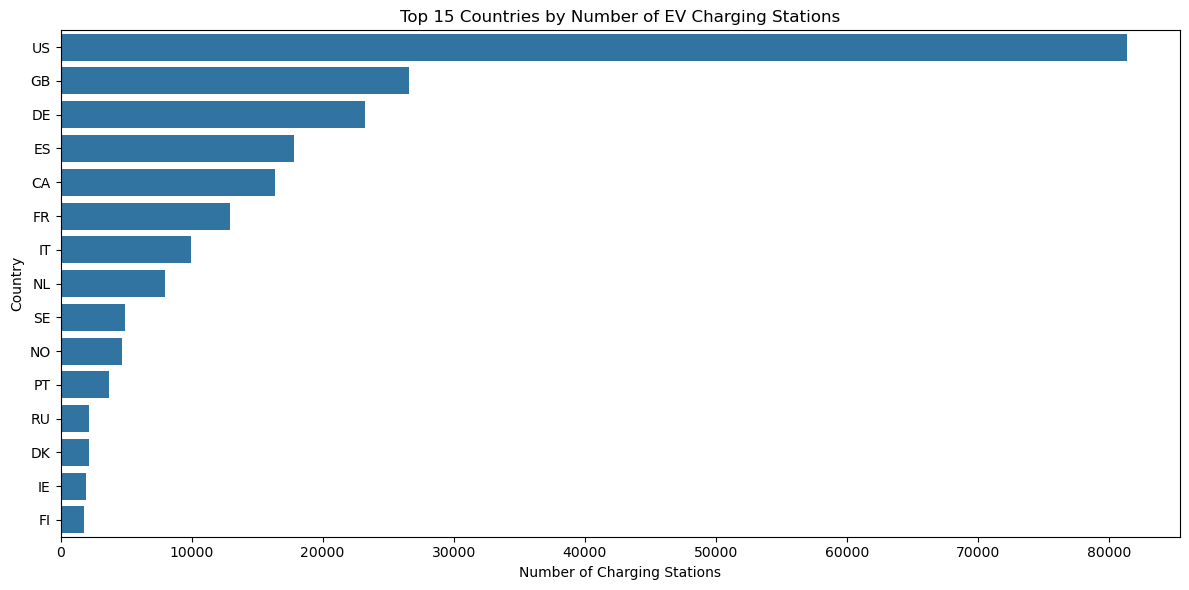

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns
top_countries = country_station_count.head(15)
plt.figure(figsize=(12, 6))
sns.barplot(data=top_countries,x='station_count',y='country_code')
plt.title('Top 15 Countries by Number of EV Charging Stations')
plt.xlabel('Number of Charging Stations')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

In [48]:
top10_percentage = (country_station_count.head(10)['station_count'].sum() / len(df_clean) * 100)
print(f"Top 10 countries account for {top10_percentage:.2f}% of all charging stations.")

Top 10 countries account for 86.56% of all charging stations.


In [49]:
country_ports = (df_clean.groupby('country_code')['ports'].sum().sort_values(ascending=False).reset_index())
country_ports.columns = ['country_code', 'total_ports']
country_ports.head(15)

,country_code,total_ports
0,US,111098
1,ES,53715
2,GB,49778
3,DE,46042
4,SE,30311
5,NO,28852
6,IT,21581
7,FR,20852
8,CA,19926
9,NL,12119


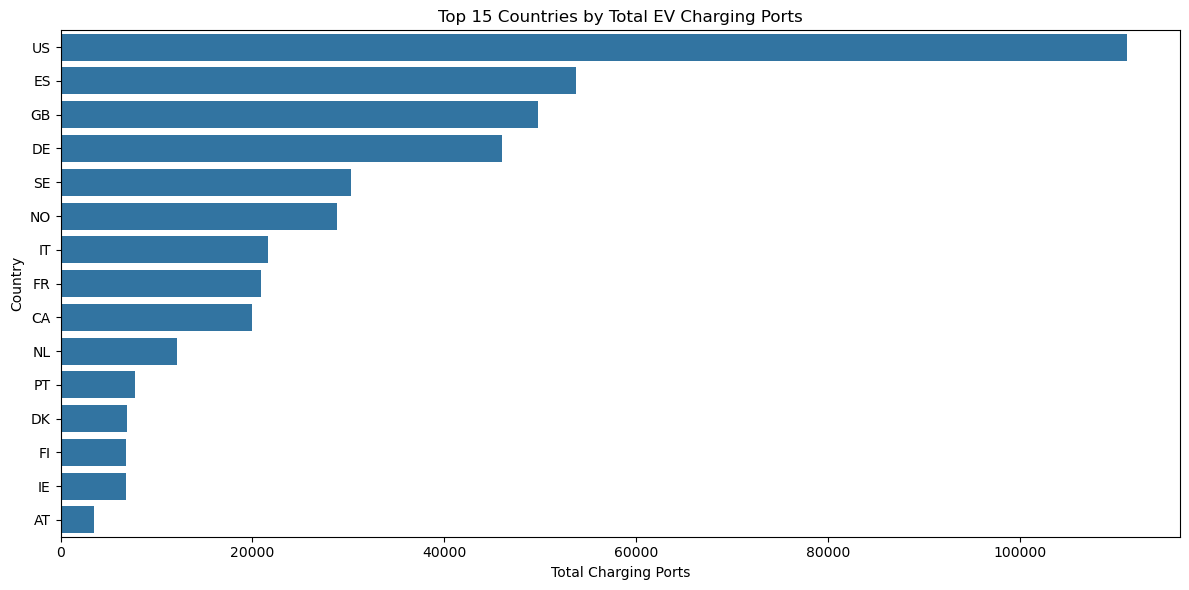

In [50]:
plt.figure(figsize=(12, 6))
sns.barplot(data=country_ports.head(15),x='total_ports',y='country_code')
plt.title('Top 15 Countries by Total EV Charging Ports')
plt.xlabel('Total Charging Ports')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

In [51]:
top10_ports_percentage = (country_ports.head(10)['total_ports'].sum() / df_clean['ports'].sum() * 100)
print(
    f"Top 10 countries account for "
    f"{top10_ports_percentage:.2f}% of all charging ports."
)

Top 10 countries account for 84.79% of all charging ports.


In [52]:
country_avg_ports = (df_clean.groupby('country_code').agg(
        total_stations=('id', 'count'),
        total_ports=('ports', 'sum')).reset_index())
country_avg_ports['avg_ports_per_station'] = (country_avg_ports['total_ports'] /country_avg_ports['total_stations'])
country_avg_ports.sort_values('avg_ports_per_station',ascending=False).head(15)

,country_code,total_stations,total_ports,avg_ports_per_station
89,PS,3,41,13.666667
42,HK,57,423,7.421053
60,KR,161,1098,6.819876
99,SE,4892,30311,6.196034
79,NO,4662,28852,6.188760
40,GI,7,36,5.142857
109,TW,162,739,4.561728
92,QA,4,18,4.500000
20,CN,5,21,4.200000
97,RW,2,8,4.000000


In [53]:
country_avg_ports_100 = country_avg_ports[country_avg_ports['total_stations'] >= 100].sort_values('avg_ports_per_station',ascending=False)
country_avg_ports_100.head(15)

,country_code,total_stations,total_ports,avg_ports_per_station
60,KR,161,1098,6.819876
99,SE,4892,30311,6.196034
79,NO,4662,28852,6.188760
109,TW,162,739,4.561728
33,FI,1770,6843,3.866102
46,IE,1926,6799,3.530114
26,DK,2151,6880,3.198512
31,ES,17795,53715,3.018545
51,IS,415,1231,2.966265
6,AT,1268,3454,2.723975


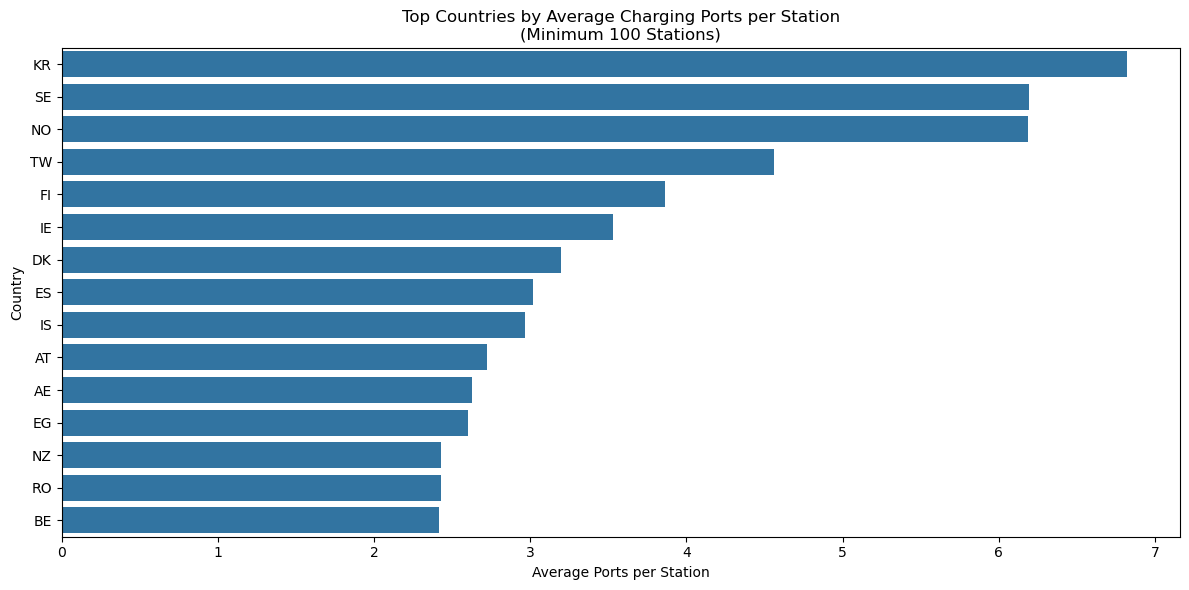

In [54]:
plt.figure(figsize=(12, 6))
sns.barplot(data=country_avg_ports_100.head(15),x='avg_ports_per_station',y='country_code')
plt.title(
    'Top Countries by Average Charging Ports per Station\n'
    '(Minimum 100 Stations)'
)
plt.xlabel('Average Ports per Station')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

In [55]:
power_class_count = ( df_clean['power_class'].value_counts().reset_index())
power_class_count.columns = ['power_class', 'station_count']
power_class_count

,power_class,station_count
0,AC_L1_(<7.5kW),107111
1,AC_HIGH_(22-49kW),55539
2,DC_FAST_(50-149kW),37328
3,AC_L2_(7.5-21kW),24238
4,DC_ULTRA_(>=150kW),13503


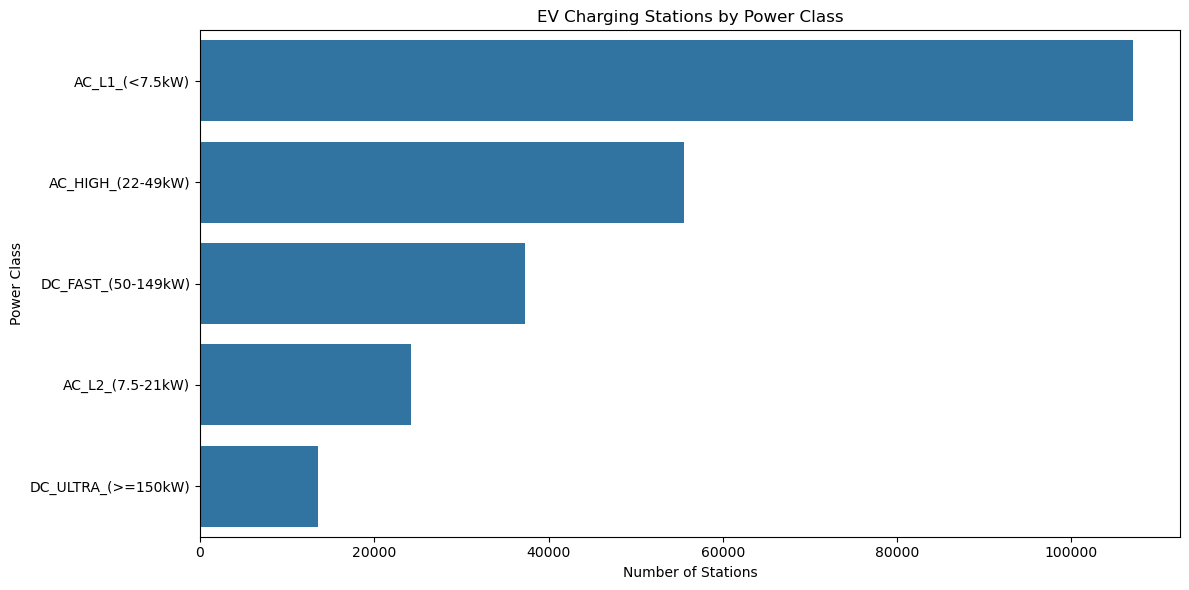

In [56]:
plt.figure(figsize=(12, 6))
sns.barplot(data=power_class_count,x='station_count',y='power_class')
plt.title('EV Charging Stations by Power Class')
plt.xlabel('Number of Stations')
plt.ylabel('Power Class')
plt.tight_layout()
plt.show()

In [57]:
power_class_count['percentage'] = (power_class_count['station_count']/ len(df_clean) * 100)
power_class_count

,power_class,station_count,percentage
0,AC_L1_(<7.5kW),107111,45.057820
1,AC_HIGH_(22-49kW),55539,23.363299
2,DC_FAST_(50-149kW),37328,15.702573
3,AC_L2_(7.5-21kW),24238,10.196072
4,DC_ULTRA_(>=150kW),13503,5.680236


In [58]:
dc_classes = ['DC_FAST_(50-149kW)','DC_ULTRA_(>=150kW)']
dc_by_country = (df_clean[df_clean['power_class'].isin(dc_classes)].groupby('country_code').size()
                 .sort_values(ascending=False).reset_index(name='dc_station_count'))
dc_by_country.head(15)

,country_code,dc_station_count
0,US,14298
1,ES,6324
2,GB,4438
3,CA,3285
4,DE,3259
5,IT,2288
6,FR,1793
7,PT,1750
8,RU,1542
9,NO,1408


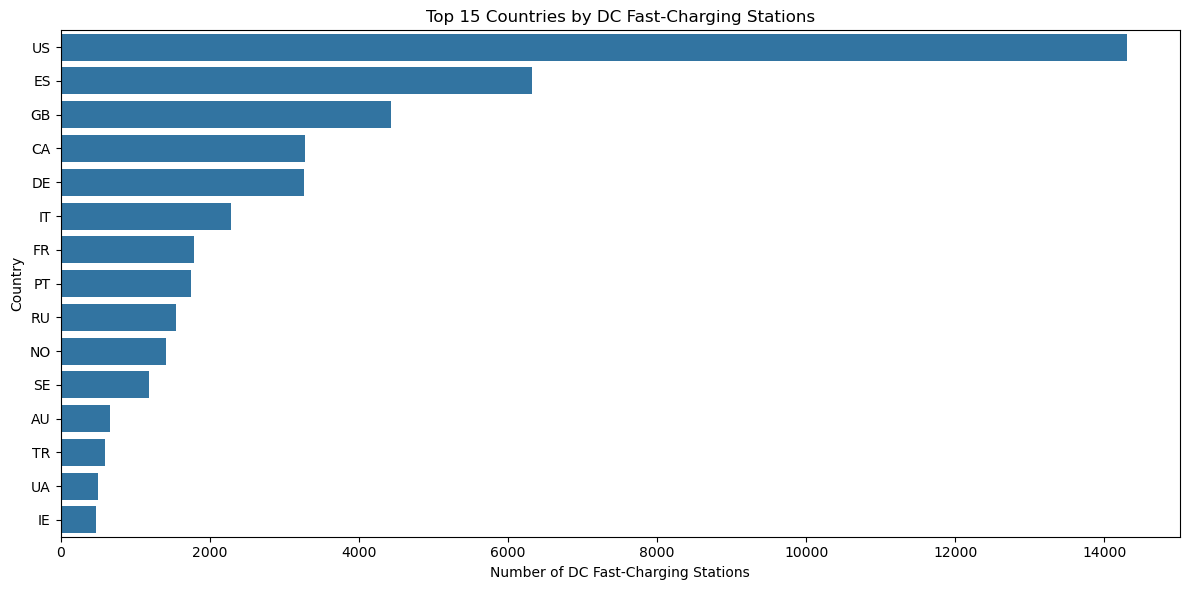

In [59]:
plt.figure(figsize=(12, 6))
sns.barplot(data=dc_by_country.head(15),x='dc_station_count',y='country_code')
plt.title('Top 15 Countries by DC Fast-Charging Stations')
plt.xlabel('Number of DC Fast-Charging Stations')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

In [66]:
country_dc_analysis = (df_clean.groupby('country_code')
    .agg(total_stations=('id', 'count'),dc_stations=('power_class', lambda x: x.isin(dc_classes).sum())).reset_index())
country_dc_analysis['dc_percentage'] = ( country_dc_analysis['dc_stations'] / country_dc_analysis['total_stations'] * 100)
country_dc_analysis = country_dc_analysis[ country_dc_analysis['total_stations'] >= 100].sort_values('dc_percentage',ascending=False)
country_dc_analysis.head(15)

,country_code,total_stations,dc_stations,dc_percentage
60,KR,161,161,100.000000
47,IL,291,276,94.845361
109,TW,162,151,93.209877
29,EE,169,156,92.307692
110,UA,555,502,90.450450
96,RU,2174,1542,70.929163
94,RO,401,279,69.576060
116,ZA,154,96,62.337662
113,UY,138,75,54.347826
7,AU,1219,662,54.306809


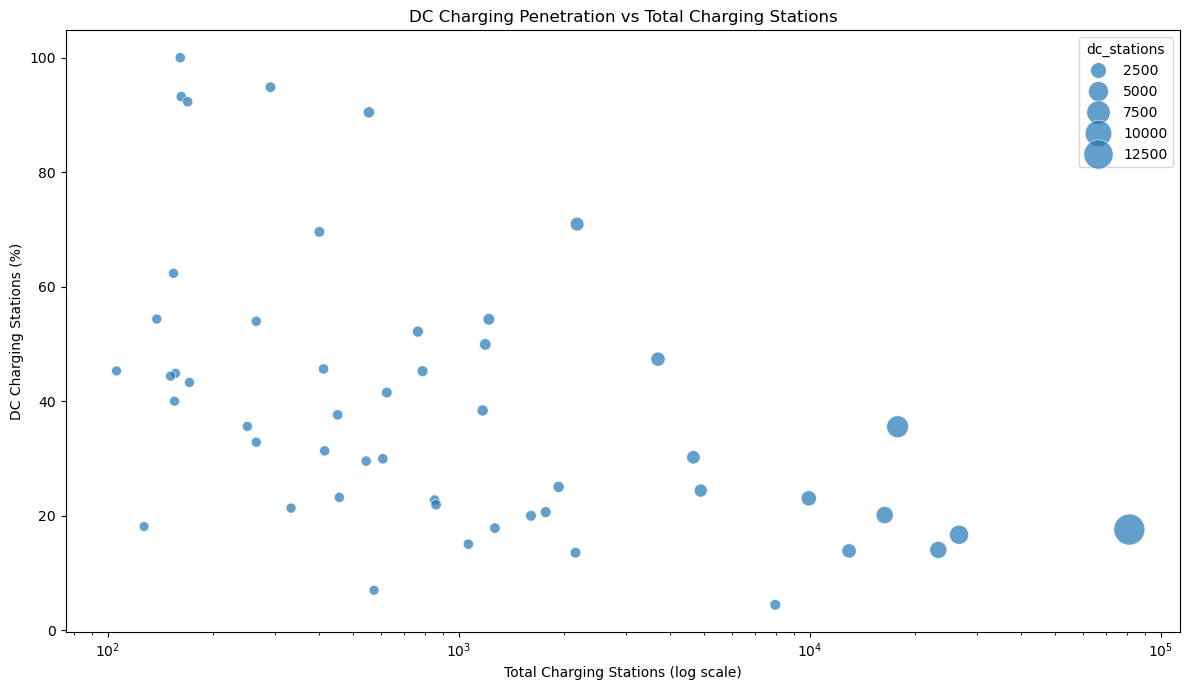

In [61]:
plt.figure(figsize=(12, 7))
sns.scatterplot(data=country_dc_analysis,x='total_stations',y='dc_percentage',size='dc_stations',sizes=(50, 500),alpha=0.7)
plt.xscale('log')
plt.title('DC Charging Penetration vs Total Charging Stations')
plt.xlabel('Total Charging Stations (log scale)')
plt.ylabel('DC Charging Stations (%)')
plt.tight_layout()
plt.show()

In [65]:
country_dc_analysis[country_dc_analysis['total_stations'] >= 500].sort_values('dc_percentage').head(15)

,country_code,total_stations,dc_stations,dc_percentage
78,NL,7977,354,4.437759
75,MX,574,40,6.968641
26,DK,2151,291,13.528591
35,FR,12945,1793,13.850908
25,DE,23240,3259,14.023236
11,BE,1065,160,15.023474
36,GB,26628,4438,16.666667
112,US,81357,14298,17.574394
6,AT,1268,226,17.823344
56,JP,1606,321,19.987547


In [64]:
country_dc_analysis[country_dc_analysis['total_stations'] >= 500].sort_values('dc_percentage',ascending=False).head(15)

,country_code,total_stations,dc_stations,dc_percentage
110,UA,555,502,90.450450
96,RU,2174,1542,70.929163
7,AU,1219,662,54.306809
64,LT,765,399,52.156863
107,TR,1190,594,49.915966
90,PT,3696,1750,47.348485
81,NZ,789,357,45.247148
14,BR,624,259,41.506410
49,IN,1170,449,38.376068
31,ES,17795,6324,35.538072


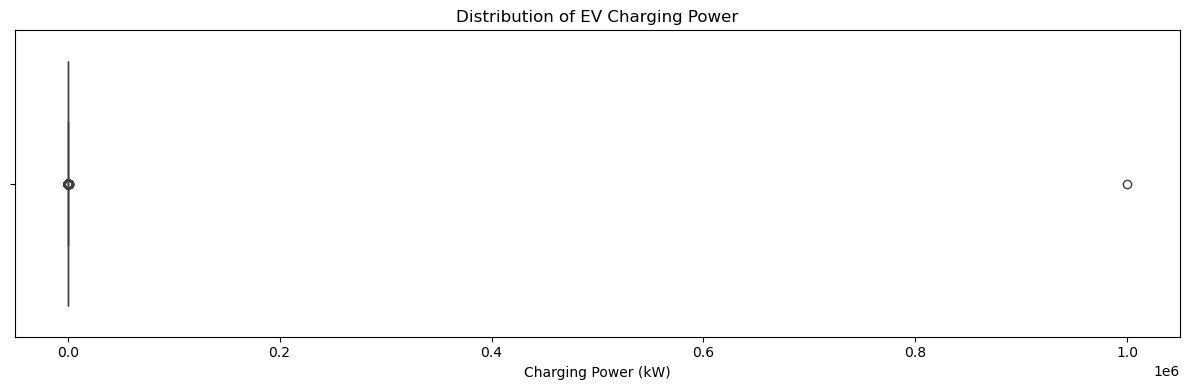

In [72]:
plt.figure(figsize=(12, 4))
sns.boxplot(x=df_clean['power_kw'])
plt.title('Distribution of EV Charging Power')
plt.xlabel('Charging Power (kW)')
plt.tight_layout()
plt.show()

In [68]:
df_clean['power_kw'].describe()

count     237719.000000
mean          35.258176
std         2051.721344
min            0.200000
25%            3.700000
50%           11.000000
75%           22.000000
max      1000000.000000
Name: power_kw, dtype: float64

In [69]:
print("Mean:", df_clean['power_kw'].mean())
print("Median:", df_clean['power_kw'].median())
print("Maximum:", df_clean['power_kw'].max())

Mean: 35.25817557704685
Median: 11.0
Maximum: 1000000.0


In [71]:
df_clean[['id', 'name', 'country_code', 'power_kw', 'power_class']] \
    .sort_values('power_kw', ascending=False) \
    .head(20)

,id,name,country_code,power_kw,power_class
113074,311284,SRM Institute of science and technology,IN,1000000.0,DC_ULTRA_(>=150kW)
127133,300087,Yangon,MM,1000.0,DC_ULTRA_(>=150kW)
56176,256766,Disfrimur - Calle Río Ebro,ES,1000.0,DC_ULTRA_(>=150kW)
142713,306657,Parking Transfronterizo Fuentes de Oñoro,PT,1000.0,DC_ULTRA_(>=150kW)
127219,273906,Supercool Mobility Center,MX,990.0,DC_ULTRA_(>=150kW)
128132,311348,JPO Commercial EV Hub by DC Handal,MY,640.0,DC_ULTRA_(>=150kW)
183073,312541,Tractor Supply Company,US,600.0,DC_ULTRA_(>=150kW)
85000,268359,MOTO Donington Park Services,GB,560.0,DC_ULTRA_(>=150kW)
128575,274104,Boerderijwinkel Lagerweij,NL,501.0,DC_ULTRA_(>=150kW)
114265,311982,Enel X Way,IT,500.0,DC_ULTRA_(>=150kW)


In [73]:
# Comparing statistics with and without the extreme 1,000,000 kW value

print("Original statistics:")
print(df_clean['power_kw'].describe())
print("\nStatistics excluding 1,000,000 kW:")
print( df_clean.loc[ df_clean['power_kw'] < 1000000,'power_kw'].describe())

Original statistics:
count     237719.000000
mean          35.258176
std         2051.721344
min            0.200000
25%            3.700000
50%           11.000000
75%           22.000000
max      1000000.000000
Name: power_kw, dtype: float64

Statistics excluding 1,000,000 kW:
count    237718.000000
mean         31.051659
std          56.341690
min           0.200000
25%           3.700000
50%          11.000000
75%          22.000000
max        1000.000000
Name: power_kw, dtype: float64


In [74]:
df_clean[df_clean['power_kw'] == 1_000_000][
    ['id', 'name', 'city', 'state_province',
     'country_code', 'ports', 'power_kw', 'power_class']
]

,id,name,city,state_province,country_code,ports,power_kw,power_class
113074,311284,SRM Institute of science and technology,chennai,Tamilnadu,IN,1,1000000.0,DC_ULTRA_(>=150kW)


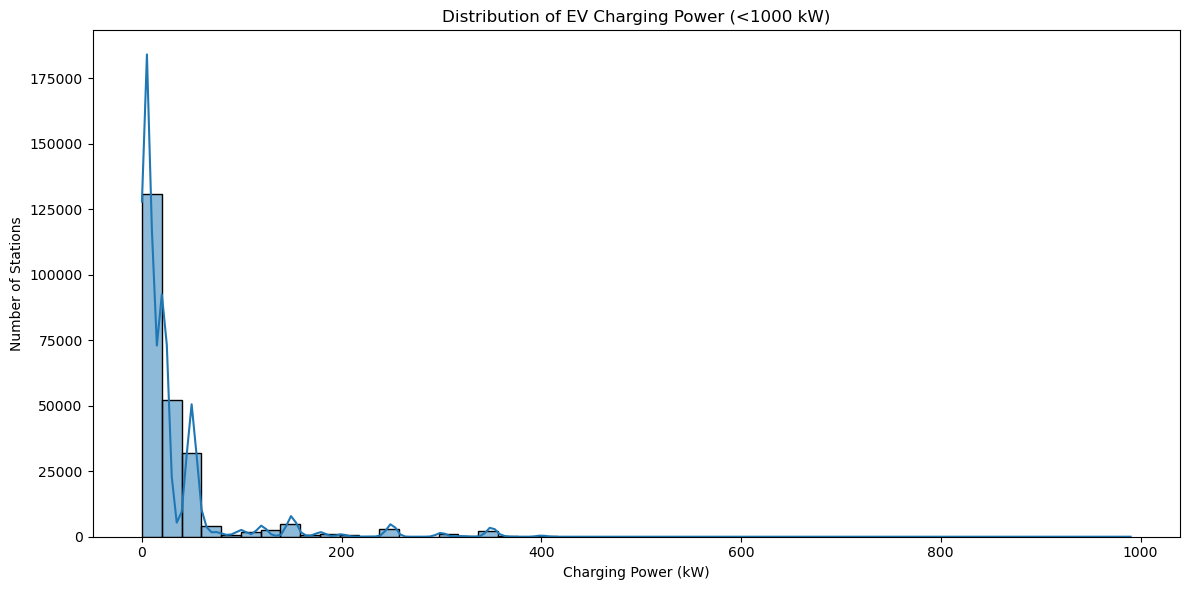

In [75]:
power_normal = df_clean[df_clean['power_kw'] < 1000]['power_kw']
plt.figure(figsize=(12, 6))
sns.histplot(power_normal,bins=50,kde=True)
plt.title('Distribution of EV Charging Power (<1000 kW)')
plt.xlabel('Charging Power (kW)')
plt.ylabel('Number of Stations')
plt.tight_layout()
plt.show()

In [76]:
# Remove the erroneous 1,000,000 kW record
df_clean = df_clean[df_clean['power_kw'] != 1_000_000].copy()
# Reset index
df_clean.reset_index(drop=True, inplace=True)
# Verify
print("Rows after removal:", len(df_clean))
print("Maximum power:", df_clean['power_kw'].max())

Rows after removal: 237718
Maximum power: 1000.0


In [77]:
df_clean['power_kw'].describe()

count    237718.000000
mean         31.051659
std          56.341690
min           0.200000
25%           3.700000
50%          11.000000
75%          22.000000
max        1000.000000
Name: power_kw, dtype: float64

In [81]:
df_clean[df_clean['power_kw'] >= 500][['id', 'name', 'country_code', 'ports', 'power_kw', 'power_class']].sort_values('power_kw', ascending=False).head(30)

,id,name,country_code,ports,power_kw,power_class
56176,256766,Disfrimur - Calle Río Ebro,ES,7,1000.0,DC_ULTRA_(>=150kW)
127132,300087,Yangon,MM,1,1000.0,DC_ULTRA_(>=150kW)
142712,306657,Parking Transfronterizo Fuentes de Oñoro,PT,24,1000.0,DC_ULTRA_(>=150kW)
127218,273906,Supercool Mobility Center,MX,1,990.0,DC_ULTRA_(>=150kW)
128131,311348,JPO Commercial EV Hub by DC Handal,MY,4,640.0,DC_ULTRA_(>=150kW)
183072,312541,Tractor Supply Company,US,6,600.0,DC_ULTRA_(>=150kW)
85000,268359,MOTO Donington Park Services,GB,14,560.0,DC_ULTRA_(>=150kW)
128574,274104,Boerderijwinkel Lagerweij,NL,1,501.0,DC_ULTRA_(>=150kW)
50208,308177,Cepsa Campo de Las Naciones,ES,6,500.0,DC_ULTRA_(>=150kW)
114264,311982,Enel X Way,IT,2,500.0,DC_ULTRA_(>=150kW)


In [82]:
print("Skewness:", df_clean['power_kw'].skew())
print("Kurtosis:", df_clean['power_kw'].kurt())

Skewness: 3.8316046686757024
Kurtosis: 17.205433741861466


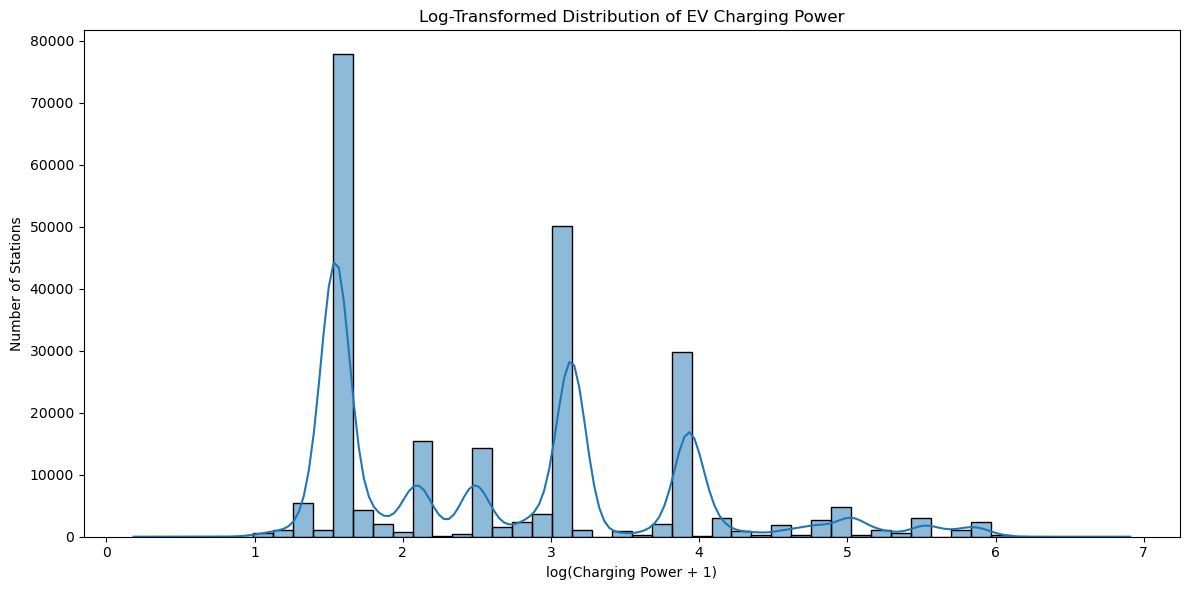

In [83]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
power_log = np.log1p(df_clean['power_kw'])
plt.figure(figsize=(12, 6))
sns.histplot(power_log, bins=50, kde=True)
plt.title('Log-Transformed Distribution of EV Charging Power')
plt.xlabel('log(Charging Power + 1)')
plt.ylabel('Number of Stations')
plt.tight_layout()
plt.show()

In [84]:
np.exp([1.6, 2.1, 2.5, 3.1, 3.8]) - 1

array([ 3.95303242,  7.16616991, 11.18249396, 21.19795128, 43.70118449])

In [85]:
df_clean['power_kw'].value_counts().head(20)

power_kw
3.7      77460
22.0     49817
50.0     28332
11.0     14072
7.0      10151
3.0       5425
150.0     4713
7.4       3474
18.0      2992
250.0     2905
60.0      2619
5.0       2567
120.0     2386
16.0      2277
350.0     2146
5.1       1788
4.8       1657
40.0      1599
100.0     1467
48.0      1280
Name: count, dtype: int64

In [86]:
df_clean.groupby('power_class')['power_kw'].agg(['count', 'min', 'median', 'max'])

,count,min,median,max
power_class,,,,
AC_HIGH_(22-49kW),55539,22.0,22.0,49.0
AC_L1_(<7.5kW),107111,0.2,3.7,7.4
AC_L2_(7.5-21kW),24238,7.5,11.0,21.6
DC_FAST_(50-149kW),37328,50.0,50.0,149.0
DC_ULTRA_(>=150kW),13502,150.0,200.0,1000.0
